# NaraHoteis — Consultoria de Dados

## Diagnóstico e Painel Gerencial

**Instituição:** SENAC RJ  
**Curso:** UC2 — Analista de Dados  
**Professor:** Cassio Ribeiro  
**Grupo:** Alexander, Gabriel, José Inacio e Sandro  

---

## Contexto

A NaraHoteis é uma rede hoteleira com 12 unidades distribuídas em 
4 regiões do estado do Rio de Janeiro.
A diretoria identificou queda de receita em algumas unidades e contratou 
uma consultoria de dados para diagnosticar a situação.

## Objetivo do Notebook

Este notebook cobre as etapas:

- **Etapa 1** — Auditoria e limpeza das 6 bases de dados recebidas
- **Etapa 2** — Análise estatística e respostas às perguntas de negócio
- **Etapa 3** — Painel visual com Matplotlib

## Bases de Dados

| Arquivo | Descrição |
|---|---|
| `reservas.csv` | Tabela fato — registros de hospedagem |
| `unidades.csv` | Dimensão — as 12 unidades da rede |
| `clientes.csv` | Dimensão — perfil dos hóspedes |
| `tipos_quarto.csv` | Dimensão — categorias e valores de diária |
| `canais_venda.csv` | Dimensão — origem das reservas |
| `funcionarios.csv` | Dimensão — equipe por unidade |

In [1]:
import pandas as pd                  # manipulação e análise de dados
import numpy as np                   # operações numéricas
import matplotlib.pyplot as plt      # visualização de dados

In [2]:
df_reservas = pd.read_csv('reservas.csv', sep=';', decimal=',')
df_unidades = pd.read_csv('unidades.csv', sep=';', decimal=',')
df_clientes = pd.read_csv('clientes.csv', sep=';', decimal=',')
df_tipos_quarto = pd.read_csv('tipos_quarto.csv', sep=';', decimal=',')
df_canais_venda = pd.read_csv('canais_venda.csv', sep=';', decimal=',')
df_funcionarios = pd.read_csv('funcionarios.csv', sep=';', decimal=',')

As bases foram todas importadas criando Date Frame com o nome da tabela, facilitando a análise específica de cada uma. Cada Data Frame deve ser analisado individualmente. Se todos juntos, viraria um amontoado de informação e ficaria difícil de documentar o que foi encontrado em cada uma.

## Auditoria — unidades

In [3]:
df_unidades.head()

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80.0
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,capital,4 estrelas,120.0
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3*,60.0
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,CAP,4 estrelas,45.0
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,Três Estrelas,50.0


Decidimos iniciar a análise pelas tabelas 'Dimensão' pois as mesmas armazenam os dados descritivos, reduzindo o tamanho e peso da tabela Fato. Se durante a auditoria for encontrado um dado na Fato que não existe na Dimensão, isso poderá ser percebido se já conhecermos a tabela Dimensão antes.

| Em 07 de fevereiro de 2026 |
---
> **Nota:** À época da auditoria, ainda não conhecíamos o conteúdo das bases. Ao longo do projeto, descobrimos que a tabela Fato exigiu a criação de novas colunas — como `valor_diaria` e `faturamento` — cruzando informações das dimensões. Isso confirmou na prática a importância de conhecer as dimensões antes de analisar a Fato.

In [4]:
df_unidades

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80.0
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,capital,4 estrelas,120.0
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3*,60.0
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,CAP,4 estrelas,45.0
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,Três Estrelas,50.0
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada fluminense,3 estrelas,55.0
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,NaN
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60.0
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 estrelas,55.0
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,NaN


In [5]:
df_unidades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_unidade         12 non-null     int64 
 1   nome_unidade       12 non-null     object
 2   cidade             12 non-null     object
 3   regiao             12 non-null     object
 4   categoria_hotel    12 non-null     object
 5   num_quartos_total  10 non-null     object
dtypes: int64(1), object(5)
memory usage: 708.0+ bytes


In [6]:
df_unidades.dtypes

id_unidade            int64
nome_unidade         object
cidade               object
regiao               object
categoria_hotel      object
num_quartos_total    object
dtype: object

### Problemas identificados — df_unidades

- regiao: valores inconsistentes — `capital`, `CAP`, `Baixada fluminense`
- categoria_hotel: sem padronização — `3*`, `Três Estrelas`, `cinco estrelas`
- Podemos observar que a coluna **`num_quartos_total`** está como **`object`** e isso é um problema. Deveria ser `int64`. Número de quartos é um dado numérico inteiro e está sendo lido como texto. Além disso, foram identificados **2 valores ausentes (NaN)**. Quais unidades?

### Agora abordaremos a tabela clientes:

In [7]:
df_clientes.head(5)

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
0,1,Otavio Reis,São Paulo,SP,18-25,PJ
1,2,Larissa Sousa,Curitiba,SC,18-25,pessoa fisica
2,3,Tatiana Coelho,Rio de Janeiro,CE,65+,Corporativo
3,4,Wilson Duarte,Brasília,AM,26-35,corporativo
4,5,Gabriela Lima,Rio de Janeiro,SP,46-55,Pessoa Física


In [8]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id_cliente     301 non-null    int64 
 1   nome           301 non-null    object
 2   cidade_origem  301 non-null    object
 3   estado_origem  301 non-null    object
 4   faixa_etaria   272 non-null    object
 5   tipo_cliente   301 non-null    object
dtypes: int64(1), object(5)
memory usage: 14.2+ KB


## Incorreções na df_clientes:
Foi observado que as colunas `cidade_origem` e `estado_origem` apresentam 
incorreções já nas primeiras 5 linhas. Vale atentar para a coluna 
`tipo_cliente` que apresenta sigla vs. extensão, com e sem acento, 
maiúscula vs. minúscula — Python é case sensitive. Além disso, a coluna 
`faixa_etaria` apresenta **272 registros** e as demais 301 registros (29 valores ausentes (NaN)).

In [9]:
df_clientes.dtypes

id_cliente        int64
nome             object
cidade_origem    object
estado_origem    object
faixa_etaria     object
tipo_cliente     object
dtype: object

In [10]:
df_clientes

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
0,1,Otavio Reis,São Paulo,SP,18-25,PJ
1,2,Larissa Sousa,Curitiba,SC,18-25,pessoa fisica
2,3,Tatiana Coelho,Rio de Janeiro,CE,65+,Corporativo
3,4,Wilson Duarte,Brasília,AM,26-35,corporativo
4,5,Gabriela Lima,Rio de Janeiro,SP,46-55,Pessoa Física
...,...,...,...,...,...,...
296,297,Roberta Leite,Curitiba,DF,56-65,pessoa fisica
297,298,Eduardo Lopes,São Paulo,ES,36-45,PJ
298,299,Vanessa Cavalcanti,Curitiba,AM,46-55,Pessoa Física
299,300,Julia Monteiro,Brasília,PR,36-45,Corporativo


Podemos observar que as colunas `cidade_origem`e `estado_origem`não estão "se entendendo"!!! Visualizem também o índex 300, id_cliente 47, Carlos Neto. Duplicado? Erro de digitação? Exportação de sistema legado? 

In [11]:
df_clientes['id_cliente'].duplicated().sum()

np.int64(1)

In [12]:
df_clientes.loc[df_clientes['id_cliente'] == 47]

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
46,47,Wesley Araujo,Recife,ES,65+,Pessoa Física
300,47,Carlos Neto,Niterói,RJ,36-45,Corporativo


Após observarmos que a última linha apresentava o `id_cliente = 47`, causou confusão, pois o mesmo não estava onde deveria. Decidimos então somar as duplicatas e em seguida realizar um filtro na coluna `id_cliente` buscando o Id 47. O filtro identificou `Wesley Araujo / Recife / ES` e `Carlos Neto / Niterói / RJ`, ambos com o mesmo Id, o que vai gerar conflito quando utilizarmos o ID como chave primária (PK) na relação entre as tabelas.

### Agora abordaremos a tabela tipos de quarto:

In [13]:
df_tipos_quarto.head(10)

,id_tipo_quarto,descricao,capacidade_max,valor_diaria_base
0,1,STANDARD,2,"R$ 280,00"
1,2,superior,2,"R$ 420,00"
2,3,Deluxe,3,"R$ 580,00"
3,4,Suite,4,"R$ 950,00"
4,5,Suíte Master,4,"R$ 1.500,00"
5,3,Deluxe,3,"R$ 580,00"


In [14]:
df_tipos_quarto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_tipo_quarto     6 non-null      int64 
 1   descricao          6 non-null      object
 2   capacidade_max     6 non-null      int64 
 3   valor_diaria_base  6 non-null      object
dtypes: int64(2), object(2)
memory usage: 324.0+ bytes


Foram observadas algumas inconsistências na tabela `tipos_quarto` como descrição toda em maiúscula, ou só a primeira letra, e a coluna `valor_diaria_base` como `object` com o símbolo de moeda brasileira (R$), 
o que causará erros em operações matemáticas. Confirmamos também que as linhas 2 e 5 são **duplicatas** — mesmo `id_tipo_quarto`, mesma descrição, mesma capacidade e mesmo valor. Esse tipo de erro pode ser ocasionado na inserção ou extração de dados de sistemas legados.

In [15]:
df_tipos_quarto.dtypes

id_tipo_quarto        int64
descricao            object
capacidade_max        int64
valor_diaria_base    object
dtype: object

### Agora abordaremos a tabela tipos de canais de venda:

In [16]:
df_canais_venda.head()

,id_canal,nome_canal,comissao_pct
0,1,Site Próprio,8%
1,2,ota,18%
2,3,Telefone,5%
3,4,agencia,12%


A tabela `canais_venda` possui apenas 4 registros, o que torna as inconsistências facilmente visíveis. A coluna `nome_canal` apresenta falta de padronização — `ota` (Online Travel Agency, como Booking e 
Expedia) e `agencia` estão em minúsculo enquanto os demais estão capitalizados. A coluna `comissao_pct` está como `object` devido ao símbolo `%`, o que impedirá cálculos de comissão.
Obs.: célula de markdown gerada pelo Cloude IA, por não sabermos do que se tratava OTA.

In [17]:
df_canais_venda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_canal      4 non-null      int64 
 1   nome_canal    4 non-null      object
 2   comissao_pct  4 non-null      object
dtypes: int64(1), object(2)
memory usage: 228.0+ bytes


In [18]:
df_canais_venda.dtypes

id_canal         int64
nome_canal      object
comissao_pct    object
dtype: object

### Agora abordaremos a tabela funcionários:

In [19]:
df_funcionarios.head(10)

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
0,1,1,Gabriela Lima,Auxiliar de Limpeza,Governança,"""2.139,00""",2020-10-05
1,2,1,Abel Correia,Segurança,Segurança,"""1.746,00""",2021-12-29
2,3,1,Sara Teixeira,analista financeiro,Financeiro,"""5.356,00""",2022-03-01
3,4,1,Julia Monteiro,Auxiliar de Limpeza,Governança,"""2.070,00""",2019-06-10
4,5,1,Daniela Ramos,Auxiliar de Limpeza,Governança,"""1.572,00""",2018-10-16
5,6,1,Lucas Souza,Auxiliar de Limpeza,Governança,"""1.955,00""",2024-02-01
6,7,1,Wilson Duarte,Recepcionista,Recepção,"""1.906,00""",2023-03-24
7,8,1,Nicolas Cunha,Recepcionista,Recepção,"""2.417,00""",2019-07-02
8,9,1,Bruno Costa,Auxiliar de Limpeza,Governança,NaN,2021-11-02
9,10,1,Bruno Costa,Manutenção,Manutenção,"""2.314,00""",2022-11-28


In [20]:
df_funcionarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id_funcionario  134 non-null    int64 
 1   id_unidade      134 non-null    int64 
 2   nome            134 non-null    object
 3   cargo           134 non-null    object
 4   departamento    134 non-null    object
 5   salario         128 non-null    object
 6   data_admissao   134 non-null    object
dtypes: int64(2), object(5)
memory usage: 7.5+ KB


In [21]:
df_funcionarios.dtypes

id_funcionario     int64
id_unidade         int64
nome              object
cargo             object
departamento      object
salario           object
data_admissao     object
dtype: object

Na tabela funcionários, mais inconsistências encontradas, a coluna salário além de estar como object, há 6 células NaN. São 134 linhas, 7 colunas. Os tipos dos Ids estão corretos, mas as datas não estão datetime e sim object. Datas precisam ser reconhecidas como data para realização de análise temporal. O funcionário Bruno Costa na s linhas 8 e 9. Podem ser duplicatas?

In [22]:
df_funcionarios.loc[df_funcionarios['nome'] == 'Bruno Costa']

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
8,9,1,Bruno Costa,Auxiliar de Limpeza,Governança,NaN,2021-11-02
9,10,1,Bruno Costa,Manutenção,Manutenção,"""2.314,00""",2022-11-28
127,128,12,Bruno Costa,Auxiliar de Limpeza,Gov.,"""1.791,00""",2022-10-27


In [23]:
df_funcionarios.duplicated().sum()

np.int64(0)

A coluna `cargo` apresenta inconsistência de capitalização — ex: `analista financeiro` em minúsculo. Foi identificado que a coluna `departamento` possui a abreviação `Gov.` na linha 127, inconsistente com o padrão `Governança` utilizado nas demais linhas. Não foram encontradas **duplicatas completas**.

### Agora sim abordaremos a tabela reservas (Tabela Fato):

In [24]:
df_reservas.head(20)

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,concluída,Cartão de Crédito
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,cancelada,PIX
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,confirmada,Transferência
5,6,4,3,179,3.0,2024-04-28,2024-05-03,5,3,10.0,confirmada,Transferência
6,7,10,2,144,2.0,2023-04-19,2023-04-24,5,1,9.0,confirmada,Dinheiro
7,8,4,4,33,3.0,2023-08-26,2023-09-02,7,2,NaN,no-show,Dinheiro
8,9,2,3,140,2.0,2024-04-04,2024-04-08,4,3,6.0,concluída,Dinheiro
9,10,5,1,48,2.0,2023-07-02,2023-07-04,2,1,2.0,confirmada,PIX


In [25]:
df_reservas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2457 entries, 0 to 2456
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_reserva         2457 non-null   int64 
 1   id_unidade         2457 non-null   int64 
 2   id_tipo_quarto     2457 non-null   int64 
 3   id_cliente         2457 non-null   int64 
 4   id_canal           2345 non-null   object
 5   data_checkin       2457 non-null   object
 6   data_checkout      2457 non-null   object
 7   qtd_diarias        2457 non-null   int64 
 8   num_hospedes       2457 non-null   int64 
 9   avaliacao_hospede  2120 non-null   object
 10  status_reserva     2457 non-null   object
 11  forma_pagamento    2457 non-null   object
dtypes: int64(6), object(6)
memory usage: 230.5+ KB


In [26]:
df_reservas['avaliacao_hospede'].unique()

array(['4.0', '1.0', '9.0', '6.0', '10.0', nan, '2.0', '8.0', '7.0',
       '11.0', '3.0', '0.0', '-3.0'], dtype=object)

A base `reservas` (Tabela Fato) apresentou inúmeras inconsistências. As colunas `id_canal` e `avaliacao_hospede` diferem da quantidade de linhas das demais (2457), evidenciando valores ausentes (NaN). As colunas `id_canal` e de datas estão como `object`, quando deveriam ser `int64` e `datetime`, respectivamente. A coluna `avaliacao_hospede`, além de estar como `object`, apresenta valores fora da escala esperada, como notas acima do máximo (`11.0`) e valores negativos (`-3.0`). São **2457 linhas, 12 colunas** e alta exigência na limpeza de dados.

COMEÇAREMOS A ANÁLISE ESTATÍSTICA

In [27]:
df_reservas     = pd.read_csv('reservas_limpa.csv',      sep=';', decimal=',')
df_unidades     = pd.read_csv('unidades_limpas.csv',     sep=',')
df_clientes     = pd.read_csv('clientes_limpas.csv',     sep=',')
df_tipos_quarto = pd.read_csv('tipos_quarto_limpo.csv',  sep=',')
df_canais_venda = pd.read_csv('canais_venda_limpas.csv', sep=',')
df_funcionarios = pd.read_csv('funcionarios_limpo.csv',  sep=',')

In [28]:
df_reservas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2457 entries, 0 to 2456
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_reserva         2457 non-null   int64  
 1   id_unidade         2457 non-null   int64  
 2   id_tipo_quarto     2457 non-null   int64  
 3   id_cliente         2457 non-null   int64  
 4   id_canal           2345 non-null   float64
 5   data_checkin       2457 non-null   object 
 6   data_checkout      2457 non-null   object 
 7   qtd_diarias        2457 non-null   int64  
 8   num_hospedes       2457 non-null   int64  
 9   avaliacao_hospede  2120 non-null   float64
 10  status_reserva     2457 non-null   object 
 11  forma_pagamento    2457 non-null   object 
dtypes: float64(2), int64(6), object(4)
memory usage: 230.5+ KB


In [29]:
df_unidades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_unidade         12 non-null     int64  
 1   nome_unidade       12 non-null     object 
 2   cidade             12 non-null     object 
 3   regiao             12 non-null     object 
 4   categoria_hotel    12 non-null     object 
 5   num_quartos_total  10 non-null     float64
dtypes: float64(1), int64(1), object(4)
memory usage: 708.0+ bytes


In [30]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id_cliente     300 non-null    int64 
 1   nome           300 non-null    object
 2   cidade_origem  300 non-null    object
 3   estado_origem  300 non-null    object
 4   faixa_etaria   271 non-null    object
 5   tipo_cliente   300 non-null    object
dtypes: int64(1), object(5)
memory usage: 14.2+ KB


In [31]:
df_tipos_quarto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_tipo_quarto     5 non-null      int64  
 1   descricao          5 non-null      object 
 2   capacidade_max     5 non-null      int64  
 3   valor_diaria_base  5 non-null      float64
dtypes: float64(1), int64(2), object(1)
memory usage: 292.0+ bytes


In [32]:
df_canais_venda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_canal      4 non-null      int64 
 1   nome_canal    4 non-null      object
 2   comissao_pct  4 non-null      int64 
dtypes: int64(2), object(1)
memory usage: 228.0+ bytes


In [33]:
df_funcionarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id_funcionario  134 non-null    int64  
 1   id_unidade      134 non-null    int64  
 2   nome            134 non-null    object 
 3   cargo           134 non-null    object 
 4   departamento    134 non-null    object 
 5   salario         128 non-null    float64
 6   data_admissao   134 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 7.5+ KB


In [34]:
df_unidades.head(20)

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80.0
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 estrelas,120.0
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 estrelas,60.0
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 estrelas,45.0
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50.0
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 estrelas,55.0
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,NaN
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 estrelas,60.0
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 estrelas,55.0
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,NaN


In [35]:
df_unidades.loc[df_unidades['id_unidade'] == 7, 'num_quartos_total'] = 65
df_unidades.loc[df_unidades['id_unidade'] == 10, 'num_quartos_total'] = 70

In [36]:
df_unidades.head(20)

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80.0
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 estrelas,120.0
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 estrelas,60.0
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 estrelas,45.0
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 estrelas,50.0
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 estrelas,55.0
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,65.0
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 estrelas,60.0
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 estrelas,55.0
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,70.0


In [37]:
df_tipos_quarto.head()

,id_tipo_quarto,descricao,capacidade_max,valor_diaria_base
0,1,Standard,2,280.0
1,2,Superior,2,420.0
2,3,Deluxe,3,580.0
3,4,Suite,4,950.0
4,5,Suíte Master,4,1500.0


In [38]:
df_tipos_quarto[['id_tipo_quarto', 'valor_diaria_base']]

,id_tipo_quarto,valor_diaria_base
0,1,280.0
1,2,420.0
2,3,580.0
3,4,950.0
4,5,1500.0


In [39]:
mapa_diaria = {
    1: 280.0,
    2: 420.0,
    3: 580.0,
    4: 950.0,
    5: 1500.0
}

In [40]:
df_reservas['valor_diaria'] = df_reservas['id_tipo_quarto'].replace(mapa_diaria)

`replace = substituir`

In [41]:
df_reservas[['id_tipo_quarto', 'valor_diaria']].head()

,id_tipo_quarto,valor_diaria
0,1,280
1,1,280
2,4,950
3,2,420
4,1,280


In [42]:
df_reservas['faturamento'] = df_reservas['qtd_diarias'] * df_reservas['valor_diaria']

Com o produto da coluna `qtd_diarias`pela coluna `valor_diaria`obtivemos a coluna `faturamento`que após sua soma, podemos decobrir a Receita da empresa.

In [43]:
df_reservas[['id_reserva', 'id_tipo_quarto', 'qtd_diarias', 'valor_diaria', 'faturamento']].head()

,id_reserva,id_tipo_quarto,qtd_diarias,valor_diaria,faturamento
0,1,1,2,280,560
1,2,1,3,280,840
2,3,4,5,950,4750
3,4,2,3,420,1260
4,5,1,7,280,1960


Chamamos especificamente estas 5 colunas para mostrar que `faturamento`existe, sendo o resultado do produto das duas anteriores.

In [44]:
df_reservas[['id_tipo_quarto', 'valor_diaria']].head()

,id_tipo_quarto,valor_diaria
0,1,280
1,1,280
2,4,950
3,2,420
4,1,280


In [45]:
df_reservas['valor_diaria'].dtype

dtype('int64')

In [46]:
df_reservas['valor_diaria'] = df_reservas['valor_diaria'].astype(float)

In [47]:
df_reservas['valor_diaria'].dtype

dtype('float64')

Foi substituído o tipo da coluna `valor_diaria`para `float`, pois tratando-se de valores monetários, existirão os decimais.



In [48]:
df_reservas['faturamento'].dtype

dtype('int64')

Faremos o mesmo com a coluna `faturamento`.

In [49]:
df_reservas['faturamento'] = df_reservas['faturamento'].astype(float) 

Agora, vamos somar toda a coluna de faturamento para descobrirmos a receita da empresa.

In [50]:
df_reservas_faturamento = df_reservas['faturamento'].sum()

In [51]:
df_reservas_faturamento

np.float64(5201900.0)

Considerando todas as 2457 reservas, a receita bruta total da NaraHoteis é R$ 5.201.900,00.

In [52]:
faturamento_por_unidade = df_reservas.groupby('id_unidade')['faturamento'].sum().sort_values(ascending=False)

In [53]:
faturamento_por_unidade

id_unidade
10    532920.0
9     512630.0
8     499150.0
6     498930.0
4     498020.0
7     486200.0
2     472200.0
12    466860.0
11    442810.0
1     427080.0
3     195140.0
5     169960.0
Name: faturamento, dtype: float64

Seria mais intuitivo apresentar aos gestores o nome da unidade ao invés do Id. Faremos então um dicionário atribuindo na `chave : valor` o id_unidade e o nome correspondente. Assim, ao substituir será apresentado o nome com o valor por unidade: 

In [54]:
mapa_unidade = {
    1: 'NaraHoteis Ipanema',
    2: 'NaraHoteis Barra da Tijuca',
    3: 'NaraHoteis Centro',
    4: 'NaraHoteis Santa Teresa',
    5: 'NaraHoteis Nova Iguaçu Centro',
    6: 'NaraHoteis Nova Iguaçu Park',
    7: 'NaraHoteis Petrópolis',
    8: 'NaraHoteis Teresópolis',
    9: 'NaraHoteis Friburgo',
    10: 'NaraHoteis Paraty',
    11: 'NaraHoteis Angra dos Reis',
    12: 'NaraHoteis Mangaratiba'
}

In [55]:
faturamento_por_unidade = faturamento_por_unidade.rename(mapa_unidade)
print(faturamento_por_unidade)

id_unidade
NaraHoteis Paraty                532920.0
NaraHoteis Friburgo              512630.0
NaraHoteis Teresópolis           499150.0
NaraHoteis Nova Iguaçu Park      498930.0
NaraHoteis Santa Teresa          498020.0
NaraHoteis Petrópolis            486200.0
NaraHoteis Barra da Tijuca       472200.0
NaraHoteis Mangaratiba           466860.0
NaraHoteis Angra dos Reis        442810.0
NaraHoteis Ipanema               427080.0
NaraHoteis Centro                195140.0
NaraHoteis Nova Iguaçu Centro    169960.0
Name: faturamento, dtype: float64


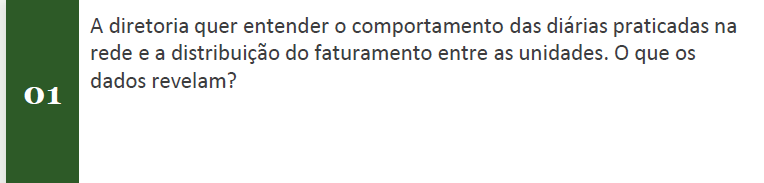

In [69]:
df_reservas['valor_diaria'].describe()

count    2457.000000
mean      569.686610
std       335.392387
min       280.000000
25%       280.000000
50%       420.000000
75%       580.000000
max      1500.000000
Name: valor_diaria, dtype: float64

In [70]:
faturamento_por_unidade.describe()

count        12.000000
mean     433491.666667
std      120862.173031
min      169960.000000
25%      438877.500000
50%      479200.000000
75%      498985.000000
max      532920.000000
Name: faturamento, dtype: float64

## Pergunta 1 — Comportamento das diárias e distribuição do faturamento

Para responder essa pergunta, foram necessárias algumas etapas de preparação dos dados, uma vez que a tabela `reservas` não contém o valor da diária — essa informação está na tabela `tipos_quarto`.

### Etapas realizadas:

**1 — Criação do dicionário `mapa_diaria`**: utilizando a tabela `df_tipos_quarto_limpo` como referência, criamos um dicionário relacionando cada `id_tipo_quarto` ao seu respectivo `valor_diaria_base`.

**2 — Criação da coluna `valor_diaria`**: o dicionário foi aplicado na tabela `reservas` via `.replace()`, criando uma nova coluna com o valor da diária correspondente a cada reserva.

**3 — Criação da coluna `faturamento`**: calculada como o produto entre `qtd_diarias` e `valor_diaria` — representando a receita gerada por cada reserva individualmente.

**4 — Agrupamento por unidade**: utilizando `.groupby()` e `.sum()`, somamos o faturamento por unidade e ordenamos do maior para o menor com `.sort_values(ascending=False)`.

**5 — Substituição dos IDs pelos nomes**: criamos o dicionário `mapa_unidade` e aplicamos `.rename()` para substituir os `id_unidade` pelos nomes reais das unidades, facilitando a leitura pela gestão da NaraHoteis.

### Resultado
A receita total da rede foi de **R$ 5.201.900,00**, com destaque positivo para **NaraHoteis Paraty** (R$ 532.920) e alerta para **NaraHoteis Nova Iguaçu Centro** (R$ 169.960) — menor faturamento da rede.

In [56]:
#Vale lembrar que a coluna id_tipo_quarto continua existindo:
df_reservas[['id_tipo_quarto', 'valor_diaria']].head()

,id_tipo_quarto,valor_diaria
0,1,280.0
1,1,280.0
2,4,950.0
3,2,420.0
4,1,280.0


O .replace() não modificou a coluna `id_tipo_quarto` — ele apenas leu os valores dela e gerou um resultado novo.
Esse resultado foi salvo numa coluna completamente nova chamada `valor_diaria`.

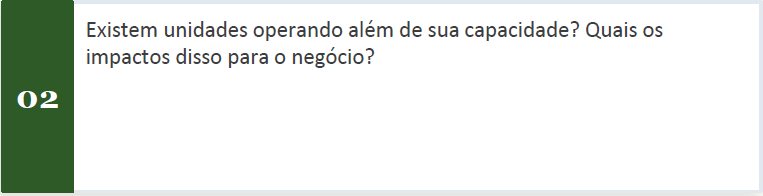

* Queremos saber se alguma unidade recebeu mais hóspedes do que seus quartos comportam.
* Quantos hóspedes foram recebidos vs quantos quartos a unidade tem.
* Quantas pessoas cada tipo de quarto comporta.

In [57]:
hospedes_por_unidade = df_reservas.groupby('id_unidade')['num_hospedes'].sum().sort_values(ascending=False)
print(hospedes_por_unidade)

id_unidade
4     410
3     407
10    406
9     396
12    376
6     374
5     369
2     356
7     356
8     352
1     349
11    343
Name: num_hospedes, dtype: int64


In [58]:
df_tipos_quarto[['id_tipo_quarto', 'capacidade_max']]


,id_tipo_quarto,capacidade_max
0,1,2
1,2,2
2,3,3
3,4,4
4,5,4


In [59]:
mapa_capacidade = {1:2, 2:2, 3:3, 4:4, 5:4}

In [60]:
df_reservas['capacidade_max'] = df_reservas['id_tipo_quarto'].replace(mapa_capacidade)

## Pergunta 2 — Unidades operando além da capacidade

Agrupamos e somamos o número de hóspedes por unidade com `.groupby()`. Em seguida, identificamos a capacidade máxima de cada tipo de quarto 
através da tabela `tipos_quarto`. Foi criado o dicionário `mapa_capacidade` relacionando `id_tipo_quarto` à sua respectiva `capacidade_max`. 
Utilizando `.replace()`, criamos uma nova coluna `capacidade_max` em `df_reservas` — permitindo comparar, reserva a reserva, quantos hóspedes 
foram recebidos versus o limite permitido pelo tipo de quarto.

In [61]:
df_reservas_acima_capacidade = df_reservas.loc[df_reservas['num_hospedes'] > df_reservas['capacidade_max']]

In [62]:
len(df_reservas_acima_capacidade)

0

### Resultado — Pergunta 2

Após comparar `num_hospedes` com `capacidade_max` reserva a reserva, o filtro retornou **0 ocorrências**. Nenhuma unidade da rede NaraHoteis
operou além de sua capacidade — todas as 2457 reservas respeitaram o limite máximo de hóspedes permitido pelo tipo de quarto reservado.

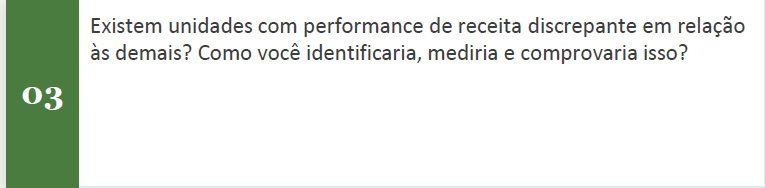

Para iniciarmos o estudo estatístico, nesse caso, não será necessário gerar um array porque já fizemos um agrupamento em `faturamento_por_unidade`.

In [63]:
Q1 = np.percentile(faturamento_por_unidade, 25)
Q3 = np.percentile(faturamento_por_unidade, 75)
IQR = Q3 - Q1

In [64]:
print(f'Q1: {Q1}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')

Q1: 438877.5
Q3: 498985.0
IQR: 60107.5


In [65]:
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f'Limite inferior: {limite_inferior}')
print(f'Limite superior: {limite_superior}')

Limite inferior: 348716.25
Limite superior: 589146.25


In [66]:
abaixo = faturamento_por_unidade.loc[faturamento_por_unidade < limite_inferior]
acima = faturamento_por_unidade.loc[faturamento_por_unidade > limite_superior]

print('Abaixo do limite inferior:')
print(abaixo)
print('Acima do limite superior:')
print(acima)

Abaixo do limite inferior:
id_unidade
NaraHoteis Centro                195140.0
NaraHoteis Nova Iguaçu Centro    169960.0
Name: faturamento, dtype: float64
Acima do limite superior:
Series([], Name: faturamento, dtype: float64)


2 unidades com performance discrepante — abaixo do limite inferior:

* NaraHoteis Centro — R$ 195.140 
* NaraHoteis Nova Iguaçu Centro — R$ 169.960 

Nenhuma unidade acima do limite superior — o topo da rede está dentro do esperado.

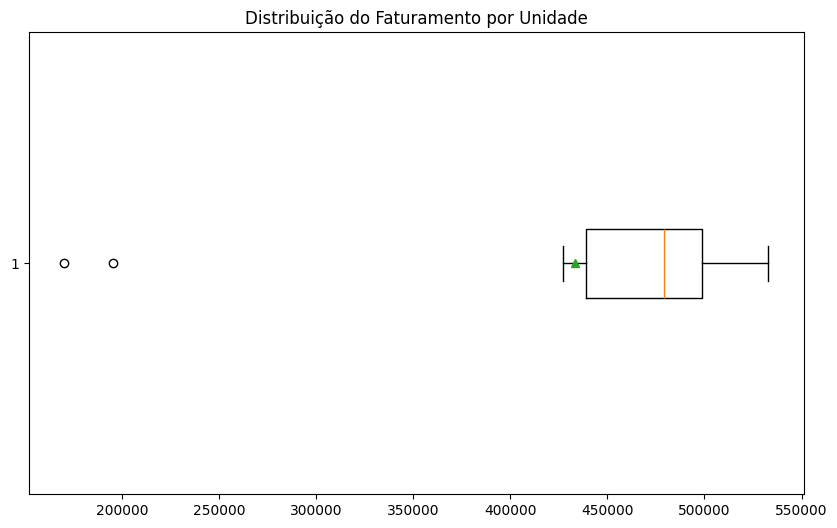

In [67]:
plt.figure(figsize=(10, 6))
plt.boxplot(faturamento_por_unidade, vert=False, showmeans=True)
plt.title('Distribuição do Faturamento por Unidade')
#plt.xlabel('Faturamento (R$)')
plt.show()

A caixa — entre ~R$ 438k e ~R$ 498k — representa o IQR.
A média foi puxada para a esquerda pelos dois outliers — está bem distante da mediana. Isso confirma que nesse caso a **mediana** é a melhor medida de tendência central para representar o faturamento típico da rede.
Os dois círculos isolados são os outliers e correspondem à **NaraHoteis Centro** e **NaraHoteis Nova Iguaçu Centro**.

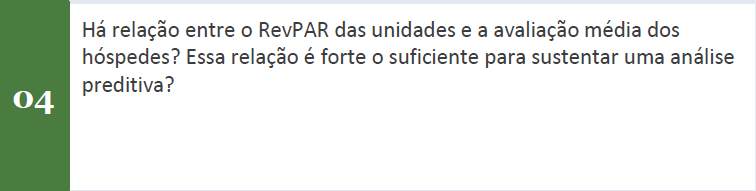

O RevPAR (Receita por Quarto Disponível) é o principal indicador de desempenho financeiro na hotelaria e em modelos de negócios baseados em capacidade ociosa. Ele mede a eficiência em gerar receita considerando todos os quartos, independentemente de estarem ocupados ou não.

In [71]:
avaliacao_por_unidade = df_reservas.groupby('id_unidade')['avaliacao_hospede'].mean()

In [72]:
print(avaliacao_por_unidade)

id_unidade
1     8.120253
2     7.886076
3     2.197628
4     8.037634
5     2.215596
6     7.981818
7     7.982036
8     8.088435
9     8.029762
10    7.813953
11    7.872611
12    7.795322
Name: avaliacao_hospede, dtype: float64


In [73]:
mapa_quartos = {
    1:  80,   # NaraHoteis Ipanema
    2:  120,  # NaraHoteis Barra da Tijuca
    3:  60,   # NaraHoteis Centro
    4:  45,   # NaraHoteis Santa Teresa
    5:  50,   # NaraHoteis Nova Iguaçu Centro
    6:  55,   # NaraHoteis Nova Iguaçu Park
    7:  65,   # NaraHoteis Petrópolis
    8:  60,   # NaraHoteis Teresópolis
    9:  55,   # NaraHoteis Friburgo
    10: 70,   # NaraHoteis Paraty
    11: 90,   # NaraHoteis Angra dos Reis
    12: 50    # NaraHoteis Mangaratiba
}

In [74]:
faturamento_id = df_reservas.groupby('id_unidade')['faturamento'].sum()
print(faturamento_id)

id_unidade
1     427080.0
2     472200.0
3     195140.0
4     498020.0
5     169960.0
6     498930.0
7     486200.0
8     499150.0
9     512630.0
10    532920.0
11    442810.0
12    466860.0
Name: faturamento, dtype: float64


In [76]:
lista_quartos = [80, 120, 60, 45, 50, 55, 65, 60, 55, 70, 90, 50]
revpar = faturamento_id / lista_quartos


In [77]:
print(revpar.sort_values(ascending=False)) #Vamos ordenar o RevPAR em ordem descrescente.

id_unidade
4     11067.111111
12     9337.200000
9      9320.545455
6      9071.454545
8      8319.166667
10     7613.142857
7      7480.000000
1      5338.500000
11     4920.111111
2      3935.000000
5      3399.200000
3      3252.333333
Name: faturamento, dtype: float64


| 4 | NaraHoteis Santa Teresa |

| 12 | NaraHoteis Mangaratiba |

| 9 | NaraHoteis Friburgo |

| 6 | NaraHoteis Nova Iguaçu Park |

| 8 | NaraHoteis Teresópolis |

| 10 | NaraHoteis Paraty |

| 7 | NaraHoteis Petrópolis |

| 1 | NaraHoteis Ipanema |

| 11 | NaraHoteis Angra dos Reis |

| 2 | NaraHoteis Barra da Tijuca |

| 5 | NaraHoteis Nova Iguaçu Centro |

| 3 | NaraHoteis Centro |


Maior eficiência por quarto (Top 3):

id_unidade 4 — NaraHoteis Santa Teresa — R$ 11.067

id_unidade 6 — NaraHoteis Nova Iguaçu Park — R$ 9.071

id_unidade 12 — NaraHoteis Mangaratiba — R$ 9.337

Menor eficiência por quarto:

id_unidade 3 — NaraHoteis Centro — R$ 3.252

id_unidade 2 — NaraHoteis Barra da Tijuca — R$ 3.935

id_unidade 5 — NaraHoteis Nova Iguaçu Centro — R$ 3.399


`Santa Teresa` lidera em RevPAR **mas não liderava em faturamento total** — tem menos quartos mas é muito eficiente. Paraty liderava em faturamento mas em RevPAR está em posição mediana.

In [78]:
correlacao = revpar.corr(avaliacao_por_unidade)
print(correlacao)

0.6378759363038278


**0,637** está na faixa de correlação forte — não moderada! Isso significa que unidades com maior RevPAR tendem a ter melhor avaliação dos hóspedes. O sinal positivo confirma que a relação é direta — quando um sobe, o outro tende a subir também.
Sim, `há relação entre RevPAR e avaliação média`. 

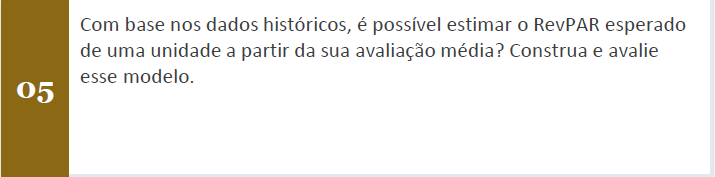

In [79]:
from sklearn.linear_model import LinearRegression

In [80]:
import pandas as pd

df_modelo = pd.DataFrame({
    'avaliacao': avaliacao_por_unidade.values,
    'revpar': revpar.values
})

X = df_modelo[['avaliacao']]
y = df_modelo['revpar']

In [81]:
modelo = LinearRegression()
modelo.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[754.86]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['avaliacao']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1636
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [82]:
X_extendido = pd.DataFrame({
    'avaliacao': [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
})

y_tend = modelo.predict(X_extendido)

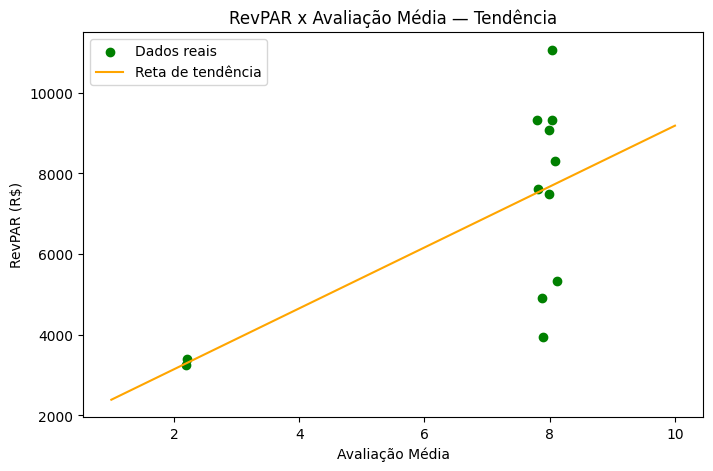

In [83]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_modelo['avaliacao'],
    df_modelo['revpar'],
    color='green',
    label='Dados reais'
)

plt.plot(
    X_extendido['avaliacao'],
    y_tend,
    color='orange',
    label='Reta de tendência'
)

plt.title('RevPAR x Avaliação Média — Tendência')
plt.xlabel('Avaliação Média')
plt.ylabel('RevPAR (R$)')
plt.legend()
plt.show()

Os dois pontos isolados à esquerda são exatamente o Centro e Nova Iguaçu Centro — os mesmos outliers que identificamos antes!
Os pontos à direita são as demais unidades com RevPAR variado.
A reta laranja — mostra a tendência positiva — quanto maior a avaliação, maior o RevPAR tende a ser.

O modelo confirma que é possível estimar o RevPAR a partir da avaliação média. A reta de tendência indica que unidades que melhoram sua avaliação tendem a apresentar RevPAR mais alto. Lembrem-se: `O modelo indica o que tende a acontecer — não uma certeza sobre o futuro`.

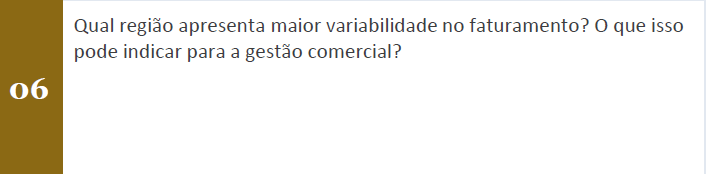

In [86]:
df_unidades[['id_unidade', 'regiao']]

,id_unidade,regiao
0,1,Capital
1,2,Capital
2,3,Capital
3,4,Capital
4,5,Baixada Fluminense
5,6,Baixada Fluminense
6,7,Serra
7,8,Serra
8,9,Serra
9,10,Costa Verde


Vamos criar o dicionário e uma lista com as regiões na mesma ordem do faturamento_id:

In [88]:
lista_regioes = [
    'Capital',           
    'Capital',           
    'Capital',           
    'Capital',           
    'Baixada Fluminense',
    'Baixada Fluminense',
    'Serra',             
    'Serra',             
    'Serra',             
    'Costa Verde',       
    'Costa Verde',       
    'Costa Verde'        
]

# Estamos criando uma lista seguindo a ordem dos Id das unidades pelas suas regiões.

In [89]:
# Agora criamos um DataFrame juntando faturamento e regiões:

df_regiao = pd.DataFrame({
    'faturamento': faturamento_id.values,
    'regiao': lista_regioes
})

In [92]:
df_regiao.head()

,faturamento,regiao
0,427080.0,Capital
1,472200.0,Capital
2,195140.0,Capital
3,498020.0,Capital
4,169960.0,Baixada Fluminense


O DataFrame foi criado corretamente. Cada faturamento está alinhado com sua região na mesma posição. A `lista_regioes` que criamos na ordem dos Id 1 a 12 garantiu esse alinhamento perfeito.


In [93]:
variabilidade = df_regiao.groupby('regiao')['faturamento'].std()
print(variabilidade)

regiao
Baixada Fluminense    232616.917807
Capital               138452.660983
Costa Verde            46658.579418
Serra                  13215.885643
Name: faturamento, dtype: float64


## Pergunta 6 — Variabilidade Regional do Faturamento

Para responder essa pergunta, criamos um novo DataFrame `df_regiao` 
combinando o faturamento por unidade (`faturamento_id`) com uma lista 
de regiões correspondentes (`lista_regioes`), seguindo a ordem dos IDs 
de 1 a 12. Em seguida, aplicamos `.groupby()` com `.std()` para calcular 
o desvio padrão do faturamento por região.

### Resultado

| Região | Desvio Padrão |
|---|---|
| Baixada Fluminense | R$ 232.616 |
| Capital | R$ 138.452 |
| Costa Verde | R$ 46.658 |
| Serra | R$ 13.215 |

### Interpretação

A **Baixada Fluminense** apresenta a **maior variabilidade** da rede — 
com apenas 2 unidades, os faturamentos são completamente opostos: 
**Nova Iguaçu Park** (R$ 498.930) e **Nova Iguaçu Centro** (R$ 169.960). 
Essa discrepância dentro da mesma região indica gestão inconsistente 
e merece atenção estratégica imediata.

A **Serra** é a região mais **homogênea** da rede — Petrópolis, 
Teresópolis e Friburgo apresentam faturamentos similares e consistentes, 
sugerindo maturidade operacional regional.

A **Capital** também apresenta variabilidade relevante, influenciada 
pelo **NaraHoteis Centro** — outlier identificado nas perguntas anteriores.

---

## Conclusão da Análise Estatística

Ao longo das 6 perguntas de negócio, a consultoria conduziu uma análise 
completa da performance da rede NaraHoteis, partindo do comportamento 
das diárias até a construção de um modelo preditivo. Os principais 
achados foram:

| Pergunta | Principal Achado |
|---|---|
| 1 | Receita total de **R$ 5.201.900** — diária mais praticada é a Standard (R$ 280) |
| 2 | Nenhuma unidade operou além da capacidade máxima |
| 3 | **NaraHoteis Centro** e **Nova Iguaçu Centro** são outliers estatísticos de faturamento |
| 4 | Correlação de **0,637** entre RevPAR e avaliação — relação forte e positiva |
| 5 | Modelo de regressão linear confirma tendência — maior avaliação tende a gerar maior RevPAR |
| 6 | **Baixada Fluminense** é a região mais inconsistente — **Serra** a mais homogênea |

### Recomendação à Diretoria

Os dados apontam para um padrão claro — as unidades **NaraHoteis Centro** 
e **NaraHoteis Nova Iguaçu Centro** são as responsáveis pela queda de 
receita identificada pela diretoria. Ambas apresentam faturamento 
abaixo do limite estatístico, RevPAR muito inferior à média da rede e 
avaliações dos hóspedes significativamente mais baixas. 

A correlação entre avaliação e RevPAR sugere que **investir na experiência 
do hóspede nessas unidades pode ser o caminho mais eficiente para 
recuperar a receita perdida**.

> *"Os dados têm uma história para contar. Cabe ao grupo descobri-la."*
> — Prof. Cassio Ribeiro